# Chapter 21 Python Lab  
## Conservative Fields, Potentials, and Green's Theorem

This lab accompanies **Chapter 21: Conservative Fields, Potentials, and Green's Theorem**.

In earlier chapters, we studied vector fields and line integrals.  
This chapter connects three major ideas:

1. **Conservative fields**: vector fields of the form $\mathbf F=\nabla f$;
2. **Potentials**: scalar functions $f$ whose gradients produce vector fields;
3. **Green's theorem**: a theorem that converts a line integral around a closed curve into a double integral over the enclosed region.

For a planar vector field

$$
\mathbf F(x,y)=\langle P(x,y),Q(x,y)\rangle,
$$

Green's theorem says, under appropriate hypotheses and positive orientation,

$$
\oint_C P\,dx+Q\,dy
=
\iint_D (Q_x-P_y)\,dA.
$$

There is also a flux form:

$$
\oint_C P\,dy-Q\,dx
=
\iint_D (P_x+Q_y)\,dA.
$$

This lab uses Python to explore:

- conservative fields and potential functions;
- numerical tests for path independence;
- reconstructing potentials from vector fields;
- circulation and scalar curl;
- Green's theorem for circles, rectangles, and general regions;
- orientation and sign;
- flux form of Green's theorem;
- numerical line integrals from parametrized and sampled curves;
- and a mini-project comparing circulation and area for complex loops.

Only `numpy` and `matplotlib` are required.

## Learning goals

By the end of this lab, you should be able to:

1. test whether a planar vector field is likely conservative;
2. find potentials for simple conservative fields;
3. verify path independence numerically;
4. compute line integrals around closed curves;
5. approximate scalar curl $Q_x-P_y$ and divergence $P_x+Q_y$;
6. use Green's theorem to compare circulation and double integrals;
7. understand the role of positive orientation;
8. use Green's theorem to compute area;
9. use the flux form of Green's theorem;
10. apply numerical Green's theorem checks to noncircular curves and sampled paths.

## Source note

This notebook was generated from the uploaded Chapter 21 QMD file.  
The extracted early headings from the source file include:

- Learning goals
- The main theme
- Gradient fields and conservative vector fields
- Potential function
- The Fundamental Theorem for Line Integrals
- Fundamental Theorem for Line Integrals
- Why the theorem is true
- Worked example: use a potential instead of parameterizing the path
- Path independence
- Equivalent ideas
- Numerical check: two paths, one answer
- How to find a potential function
- Worked example: a conservative field
- The component test in the plane

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
norm = np.linalg.norm

def make_grid(xmin=-3, xmax=3, ymin=-3, ymax=3, n=25):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y

def make_dense_grid(xmin=-3, xmax=3, ymin=-3, ymax=3, n=350):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y

def safe_eval_2d(f, X, Y):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        Z = f(X, Y)
    return np.asarray(Z, dtype=float)

def vector_magnitude(U, V):
    return np.sqrt(U**2 + V**2)

def unit_vector_field(U, V, eps=1e-12):
    M = vector_magnitude(U, V)
    return U/(M+eps), V/(M+eps), M

def plot_vector_field(F, xmin=-3, xmax=3, ymin=-3, ymax=3, n=23,
                      normalize=True, title="Vector field"):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n=n)
    U, V = F(X, Y)
    M = vector_magnitude(U, V)
    if normalize:
        Uplot, Vplot, _ = unit_vector_field(U, V)
    else:
        Uplot, Vplot = U, V
    plt.figure(figsize=(7, 6))
    plt.quiver(X, Y, Uplot, Vplot, M)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True, alpha=0.25)
    plt.show()
    return X, Y, U, V, M

def plot_scalar_contours(f, xmin=-3, xmax=3, ymin=-3, ymax=3, levels=22,
                         title="Scalar field contours", path=None, point=None):
    x, y, X, Y = make_dense_grid(xmin, xmax, ymin, ymax, n=350)
    Z = safe_eval_2d(f, X, Y)
    plt.figure(figsize=(7, 6))
    cs = plt.contour(X, Y, Z, levels=levels)
    plt.clabel(cs, inline=True, fontsize=8)
    if path is not None:
        plt.plot(path[:,0], path[:,1], linewidth=3)
        plt.scatter([path[0,0]], [path[0,1]], s=70, label="start")
        plt.scatter([path[-1,0]], [path[-1,1]], s=70, label="end")
        plt.legend()
    if point is not None:
        plt.scatter([point[0]], [point[1]], s=90)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True, alpha=0.25)
    plt.show()
    return X, Y, Z

def finite_partial_x(g, X, Y, h=1e-5):
    return (g(X+h, Y) - g(X-h, Y))/(2*h)

def finite_partial_y(g, X, Y, h=1e-5):
    return (g(X, Y+h) - g(X, Y-h))/(2*h)

def numerical_scalar_curl(F, X, Y, h=1e-5):
    P = lambda x, y: F(x, y)[0]
    Q = lambda x, y: F(x, y)[1]
    return finite_partial_x(Q, X, Y, h=h) - finite_partial_y(P, X, Y, h=h)

def numerical_divergence(F, X, Y, h=1e-5):
    P = lambda x, y: F(x, y)[0]
    Q = lambda x, y: F(x, y)[1]
    return finite_partial_x(P, X, Y, h=h) + finite_partial_y(Q, X, Y, h=h)

def vector_line_integral(F, r, rp, a, b, n=3000):
    t = np.linspace(a, b, n)
    X, Y = r(t)
    dX, dY = rp(t)
    P, Q = F(X, Y)
    integrand = P*dX + Q*dY
    return float(np.trapezoid(integrand, t)), t, X, Y, P, Q, dX, dY, integrand

def flux_line_integral(F, r, rp, a, b, n=3000):
    """
    Compute outward flux integral ∮ F·n ds for a positively oriented curve.
    If r(t) is positively oriented, outward normal times ds is <dy, -dx>.
    Thus flux = ∮ P dy - Q dx.
    """
    t = np.linspace(a, b, n)
    X, Y = r(t)
    dX, dY = rp(t)
    P, Q = F(X, Y)
    integrand = P*dY - Q*dX
    return float(np.trapezoid(integrand, t)), t, X, Y, integrand

def sampled_vector_line_integral(F, points):
    """
    Approximate ∫ F·dr along a sampled polyline.
    """
    points = np.asarray(points, dtype=float)
    dr = points[1:] - points[:-1]
    mids = 0.5*(points[1:] + points[:-1])
    P, Q = F(mids[:,0], mids[:,1])
    contrib = P*dr[:,0] + Q*dr[:,1]
    return float(np.sum(contrib)), mids, dr, contrib

def sampled_flux_line_integral(F, points):
    """
    Approximate ∮ P dy - Q dx along a sampled positively oriented polyline.
    """
    points = np.asarray(points, dtype=float)
    dr = points[1:] - points[:-1]
    mids = 0.5*(points[1:] + points[:-1])
    P, Q = F(mids[:,0], mids[:,1])
    contrib = P*dr[:,1] - Q*dr[:,0]
    return float(np.sum(contrib)), mids, dr, contrib

def sampled_area_signed(points):
    """
    Signed area by shoelace formula.
    Positive means counterclockwise orientation.
    """
    points = np.asarray(points, dtype=float)
    if norm(points[0] - points[-1]) > 1e-12:
        points = np.vstack([points, points[0]])
    x = points[:,0]
    y = points[:,1]
    return 0.5*np.sum(x[:-1]*y[1:] - y[:-1]*x[1:])

def close_polyline(points):
    points = np.asarray(points, dtype=float)
    if norm(points[0] - points[-1]) > 1e-12:
        points = np.vstack([points, points[0]])
    return points

def piecewise_points(vertices, points_per_segment=300, closed=False):
    vertices = np.asarray(vertices, dtype=float)
    if closed:
        vertices = close_polyline(vertices)
    pts = []
    for i in range(len(vertices)-1):
        a = vertices[i]
        b = vertices[i+1]
        t = np.linspace(0, 1, points_per_segment, endpoint=False)
        pts.append(a[None,:] + t[:,None]*(b-a)[None,:])
    pts.append(vertices[-1][None,:])
    return np.vstack(pts)

def plot_path(points, xmin=None, xmax=None, ymin=None, ymax=None, title="Path", show_orientation=True):
    points = np.asarray(points, dtype=float)
    plt.figure(figsize=(7, 6))
    plt.plot(points[:,0], points[:,1], linewidth=3)
    plt.scatter([points[0,0]], [points[0,1]], s=80, label="start")
    plt.scatter([points[-1,0]], [points[-1,1]], s=80, label="end")
    if show_orientation and len(points) > 10:
        idxs = np.linspace(5, len(points)-6, 6, dtype=int)
        for idx in idxs:
            v = points[idx+1] - points[idx-1]
            L = norm(v)
            if L > 0:
                plt.arrow(points[idx,0], points[idx,1], 0.16*v[0]/L, 0.16*v[1]/L,
                          head_width=0.06, length_includes_head=True)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    if xmin is not None:
        plt.xlim(xmin, xmax)
        plt.ylim(ymin, ymax)
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

def plot_path_in_field(F, points, xmin=-3, xmax=3, ymin=-3, ymax=3, title="Path in vector field"):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n=23)
    U, V = F(X, Y)
    U, V, _ = unit_vector_field(U, V)
    points = np.asarray(points)
    plt.figure(figsize=(7, 6))
    plt.quiver(X, Y, U, V, alpha=0.45)
    plt.plot(points[:,0], points[:,1], linewidth=3)
    plt.scatter([points[0,0]], [points[0,1]], s=80, label="start")
    plt.scatter([points[-1,0]], [points[-1,1]], s=80, label="end")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

def midpoint_region_integral(g, xmin, xmax, ymin, ymax, mask, nx=500, ny=500):
    dx = (xmax-xmin)/nx
    dy = (ymax-ymin)/ny
    xmid = xmin + (np.arange(nx)+0.5)*dx
    ymid = ymin + (np.arange(ny)+0.5)*dy
    X, Y = np.meshgrid(xmid, ymid)
    inside = mask(X, Y)
    Z = safe_eval_2d(g, X, Y)
    return float(np.sum(Z[inside])*dx*dy), X, Y, Z, inside

def disk_mask_radius(R):
    return lambda X, Y: X**2 + Y**2 <= R**2

def rectangle_mask(a, b, c, d):
    return lambda X, Y: (a <= X) & (X <= b) & (c <= Y) & (Y <= d)

print("Setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-wup2pfcb because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup complete.


---

# Part I. Conservative fields and potentials

A vector field

$$
\mathbf F=\langle P,Q\rangle
$$

is **conservative** if there is a scalar potential $f$ such that

$$
\mathbf F=\nabla f=\langle f_x,f_y\rangle.
$$

If $\mathbf F$ is conservative, then line integrals are path independent:

$$
\int_C \mathbf F\cdot d\mathbf r=f(B)-f(A).
$$

## 1. A simple conservative field

Let

$$
f(x,y)=x^2y+\sin y.
$$

Then

$$
\nabla f=\langle 2xy,\;x^2+\cos y\rangle.
$$

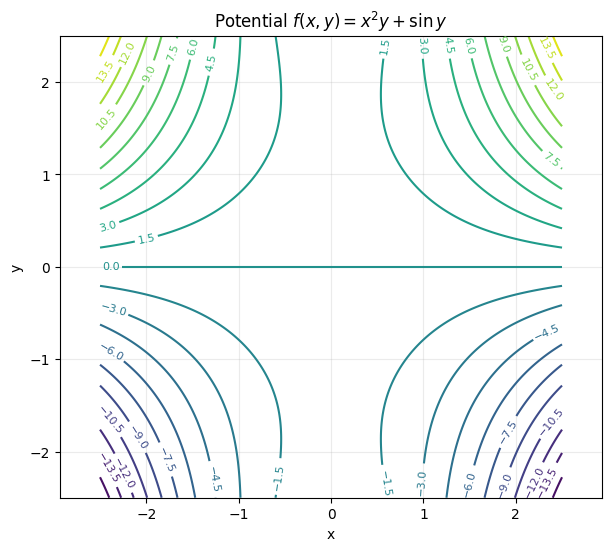

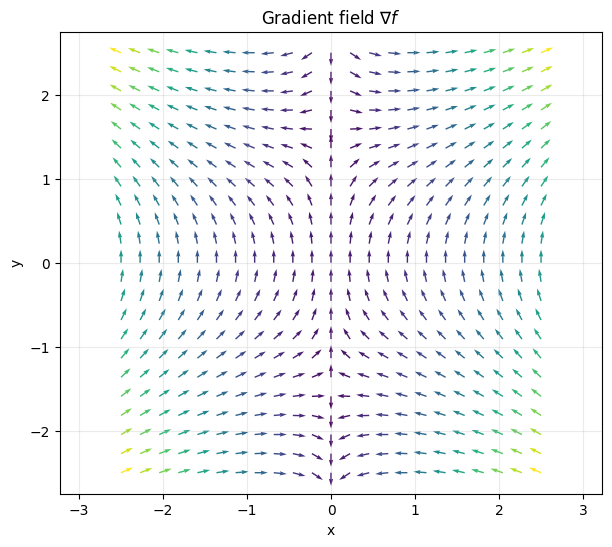

(array([[-2.5     , -2.272727, -2.045455, -1.818182, -1.590909, -1.363636,
         -1.136364, -0.909091, -0.681818, -0.454545, -0.227273,  0.      ,
          0.227273,  0.454545,  0.681818,  0.909091,  1.136364,  1.363636,
          1.590909,  1.818182,  2.045455,  2.272727,  2.5     ],
        [-2.5     , -2.272727, -2.045455, -1.818182, -1.590909, -1.363636,
         -1.136364, -0.909091, -0.681818, -0.454545, -0.227273,  0.      ,
          0.227273,  0.454545,  0.681818,  0.909091,  1.136364,  1.363636,
          1.590909,  1.818182,  2.045455,  2.272727,  2.5     ],
        [-2.5     , -2.272727, -2.045455, -1.818182, -1.590909, -1.363636,
         -1.136364, -0.909091, -0.681818, -0.454545, -0.227273,  0.      ,
          0.227273,  0.454545,  0.681818,  0.909091,  1.136364,  1.363636,
          1.590909,  1.818182,  2.045455,  2.272727,  2.5     ],
        [-2.5     , -2.272727, -2.045455, -1.818182, -1.590909, -1.363636,
         -1.136364, -0.909091, -0.681818, -0.454545, -0

In [2]:
def potential_f(X, Y):
    return X**2*Y + np.sin(Y)

def F_conservative(X, Y):
    return 2*X*Y, X**2 + np.cos(Y)

plot_scalar_contours(
    potential_f,
    xmin=-2.5, xmax=2.5,
    ymin=-2.5, ymax=2.5,
    levels=24,
    title=r"Potential $f(x,y)=x^2y+\sin y$"
)

plot_vector_field(
    F_conservative,
    xmin=-2.5, xmax=2.5,
    ymin=-2.5, ymax=2.5,
    n=23,
    normalize=True,
    title=r"Gradient field $\nabla f$"
)

## 2. Path independence check

Move from

$$
A=(0,0)
$$

to

$$
B=(1,1)
$$

along two paths:

1. straight line $\mathbf r_1(t)=\langle t,t\rangle$;
2. parabola $\mathbf r_2(t)=\langle t,t^2\rangle$.

For a conservative field, both work integrals should equal $f(B)-f(A)$.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Straight path integral: 1.8414710326039128
Parabola path integral: 1.8414710562881416
Potential difference: 1.8414709848078965
Differences: 4.7796016255929885e-08 7.148024505632122e-08


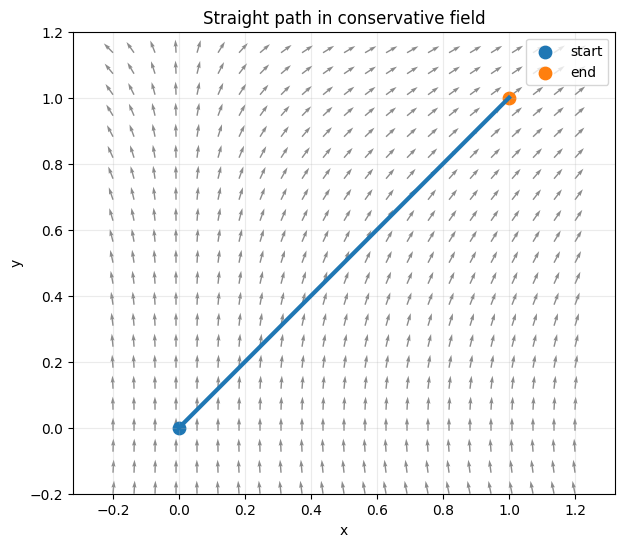

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


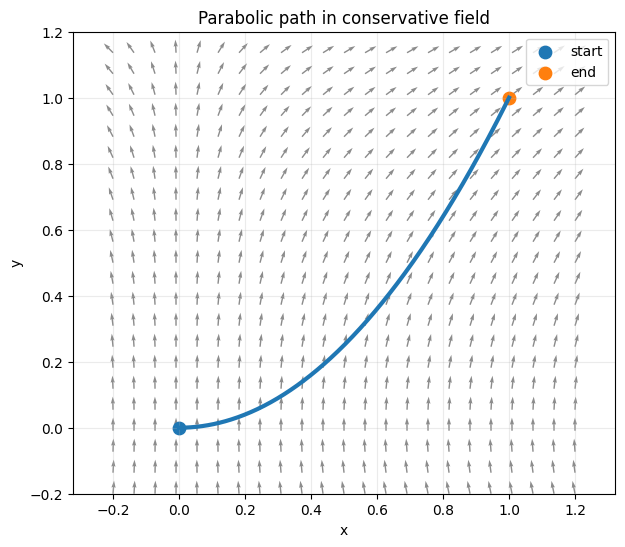

In [3]:
def r_straight(t):
    return t, t

def rp_straight(t):
    return np.ones_like(t), np.ones_like(t)

def r_parabola(t):
    return t, t**2

def rp_parabola(t):
    return np.ones_like(t), 2*t

I_straight, t, Xs, Ys, *_ = vector_line_integral(F_conservative, r_straight, rp_straight, 0, 1)
I_parabola, *_ = vector_line_integral(F_conservative, r_parabola, rp_parabola, 0, 1)

delta_potential = potential_f(1, 1) - potential_f(0, 0)

print("Straight path integral:", I_straight)
print("Parabola path integral:", I_parabola)
print("Potential difference:", delta_potential)
print("Differences:", I_straight-delta_potential, I_parabola-delta_potential)

path1 = np.column_stack(r_straight(np.linspace(0,1,400)))
path2 = np.column_stack(r_parabola(np.linspace(0,1,400)))

plot_path_in_field(F_conservative, path1, xmin=-0.2, xmax=1.2, ymin=-0.2, ymax=1.2,
                   title="Straight path in conservative field")
plot_path_in_field(F_conservative, path2, xmin=-0.2, xmax=1.2, ymin=-0.2, ymax=1.2,
                   title="Parabolic path in conservative field")

## 3. Closed curve test for a conservative field

If $\mathbf F=\nabla f$, then every closed curve integral is zero:

$$
\oint_C \nabla f\cdot d\mathbf r=0.
$$

We check this on the unit circle.

In [4]:
def r_unit_circle(t):
    return np.cos(t), np.sin(t)

def rp_unit_circle(t):
    return -np.sin(t), np.cos(t)

closed_integral, *_ = vector_line_integral(F_conservative, r_unit_circle, rp_unit_circle, 0, 2*np.pi, n=6000)

print("Closed curve integral for conservative field:", closed_integral)

Closed curve integral for conservative field: -5.551115123125783e-16


---

# Part II. Testing whether a field is conservative

If

$$
\mathbf F=\langle P,Q\rangle=\nabla f
$$

and $P,Q$ have continuous partial derivatives, then

$$
P_y=Q_x.
$$

Equivalently,

$$
Q_x-P_y=0.
$$

The expression

$$
Q_x-P_y
$$

is the planar scalar curl.

On a simply connected region, a smooth field with $Q_x-P_y=0$ is conservative.

## 4. Scalar curl of a conservative field

In [5]:
probe_points = [(0,0), (0.5, 0.7), (-1.2, 1.1), (2.0, -0.8)]

for x0, y0 in probe_points:
    curl = numerical_scalar_curl(F_conservative, x0, y0)
    print(f"point ({x0:5.2f},{y0:5.2f}): scalar curl = {curl: .3e}")

point ( 0.00, 0.00): scalar curl =  0.000e+00
point ( 0.50, 0.70): scalar curl =  0.000e+00
point (-1.20, 1.10): scalar curl =  1.110e-11
point ( 2.00,-0.80): scalar curl =  4.441e-11


## 5. A nonconservative rotational field

Let

$$
\mathbf F(x,y)=\langle -y,x\rangle.
$$

Here

$$
P=-y,\qquad Q=x,
$$

so

$$
Q_x-P_y=1-(-1)=2.
$$

This field has nonzero circulation around the origin.

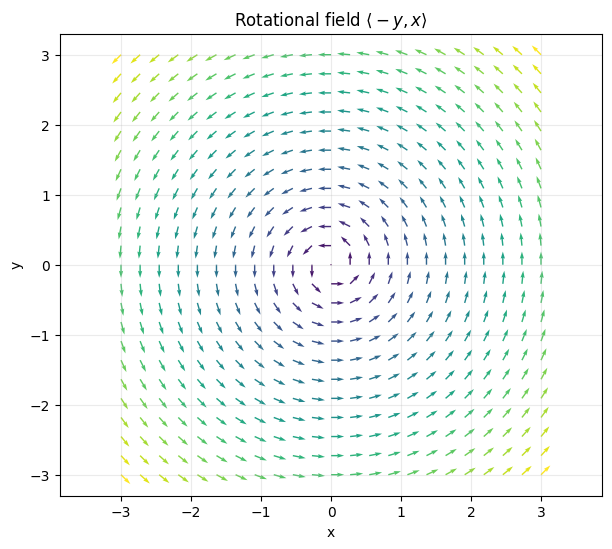

point ( 0.00, 0.00): scalar curl =  2.000000
point ( 0.50, 0.70): scalar curl =  2.000000
point (-1.20, 1.10): scalar curl =  2.000000
point ( 2.00,-0.80): scalar curl =  2.000000


In [6]:
def F_rotational(X, Y):
    return -Y, X

plot_vector_field(
    F_rotational,
    xmin=-3, xmax=3,
    ymin=-3, ymax=3,
    n=23,
    normalize=True,
    title=r"Rotational field $\langle -y,x\rangle$"
)

for x0, y0 in probe_points:
    curl = numerical_scalar_curl(F_rotational, x0, y0)
    print(f"point ({x0:5.2f},{y0:5.2f}): scalar curl = {curl: .6f}")

## 6. Path dependence in a nonconservative field

Compare the same two paths from $(0,0)$ to $(1,1)$.

In [7]:
J_straight, *_ = vector_line_integral(F_rotational, r_straight, rp_straight, 0, 1)
J_parabola, *_ = vector_line_integral(F_rotational, r_parabola, rp_parabola, 0, 1)

print("Rotational field, straight path:", J_straight)
print("Rotational field, parabola path:", J_parabola)
print("Difference:", J_parabola - J_straight)

Rotational field, straight path: 0.0
Rotational field, parabola path: 0.3333333518642037
Difference: 0.3333333518642037


---

# Part III. Reconstructing a potential

Suppose

$$
\mathbf F=\langle P,Q\rangle
$$

is conservative and we want to find $f$ such that

$$
f_x=P,\qquad f_y=Q.
$$

A typical workflow is:

1. integrate $P$ with respect to $x$;
2. include an unknown function of $y$;
3. differentiate with respect to $y$;
4. match $Q$.

## 7. Potential reconstruction example

Let

$$
\mathbf F(x,y)=\langle 2xy+3x^2,\;x^2+4y\rangle.
$$

Since

$$
P_y=2x,\qquad Q_x=2x,
$$

the field is conservative on the plane.

Integrate

$$
f_x=2xy+3x^2
$$

with respect to $x$:

$$
f(x,y)=x^2y+x^3+g(y).
$$

Then

$$
f_y=x^2+g'(y).
$$

Matching $Q=x^2+4y$ gives $g'(y)=4y$, so $g(y)=2y^2$.

Thus one potential is

$$
f(x,y)=x^2y+x^3+2y^2.
$$

In [8]:
def F_reconstruct(X, Y):
    return 2*X*Y + 3*X**2, X**2 + 4*Y

def potential_reconstruct(X, Y):
    return X**2*Y + X**3 + 2*Y**2

for x0, y0 in [(0,0), (1,1), (-1,2), (0.5,-0.7)]:
    P, Q = F_reconstruct(x0, y0)
    curl = numerical_scalar_curl(F_reconstruct, x0, y0)
    print(f"point ({x0:5.2f},{y0:5.2f}): F=({P: .4f},{Q: .4f}), curl={curl: .2e}")

A = np.array([-1.0, 0.5])
B = np.array([1.2, 1.1])

def r_AB_line(t):
    return A[0] + t*(B[0]-A[0]), A[1] + t*(B[1]-A[1])

def rp_AB_line(t):
    return (B[0]-A[0])*np.ones_like(t), (B[1]-A[1])*np.ones_like(t)

I_AB, *_ = vector_line_integral(F_reconstruct, r_AB_line, rp_AB_line, 0, 1)
delta = potential_reconstruct(B[0], B[1]) - potential_reconstruct(A[0], A[1])

print("\nLine integral from A to B:", I_AB)
print("Potential difference:", delta)

point ( 0.00, 0.00): F=( 0.0000, 0.0000), curl= 0.00e+00
point ( 1.00, 1.00): F=( 5.0000, 5.0000), curl= 0.00e+00
point (-1.00, 2.00): F=(-1.0000, 9.0000), curl= 0.00e+00
point ( 0.50,-0.70): F=( 0.0500,-2.5500), curl= 1.11e-11

Line integral from A to B: 5.732000753391067
Potential difference: 5.732


### Guided task 1

Test whether

$$
\mathbf F(x,y)=\langle y+2x,\;x+2y\rangle
$$

is conservative. If so, find a potential and check a line integral from $(0,0)$ to $(1,2)$.

In [9]:
def F_task1(X, Y):
    return Y + 2*X, X + 2*Y

def potential_task1(X, Y):
    return X*Y + X**2 + Y**2

A1 = np.array([0.0, 0.0])
B1 = np.array([1.0, 2.0])

def r_task1(t):
    return A1[0] + t*(B1[0]-A1[0]), A1[1] + t*(B1[1]-A1[1])

def rp_task1(t):
    return (B1[0]-A1[0])*np.ones_like(t), (B1[1]-A1[1])*np.ones_like(t)

I_task1, *_ = vector_line_integral(F_task1, r_task1, rp_task1, 0, 1)
delta_task1 = potential_task1(B1[0], B1[1]) - potential_task1(A1[0], A1[1])

print("curl at (0.5,0.5):", numerical_scalar_curl(F_task1, 0.5, 0.5))
print("line integral:", I_task1)
print("potential difference:", delta_task1)

curl at (0.5,0.5): 0.0
line integral: 7.0
potential difference: 7.0


---

# Part IV. Green's theorem: circulation form

Let $C$ be a positively oriented, simple, closed curve enclosing a region $D$.

For

$$
\mathbf F=\langle P,Q\rangle,
$$

Green's theorem says

$$
\oint_C P\,dx+Q\,dy
=
\iint_D (Q_x-P_y)\,dA.
$$

The quantity $Q_x-P_y$ is the planar scalar curl.

## 8. Green's theorem on a circle for the rotational field

For

$$
\mathbf F=\langle -y,x\rangle,
$$

the scalar curl is

$$
Q_x-P_y=2.
$$

For a circle of radius $R$,

$$
\oint_C \mathbf F\cdot d\mathbf r
=
\iint_D 2\,dA
=
2\pi R^2.
$$

In [10]:
def make_circle(R):
    def r(t):
        return R*np.cos(t), R*np.sin(t)
    def rp(t):
        return -R*np.sin(t), R*np.cos(t)
    return r, rp

for R in [0.5, 1.0, 2.0, 3.0]:
    rR, rpR = make_circle(R)
    line_val, *_ = vector_line_integral(F_rotational, rR, rpR, 0, 2*np.pi, n=6000)
    green_val = 2*np.pi*R**2
    print(f"R={R:3.1f}: line integral={line_val:12.6f}, Green prediction={green_val:12.6f}")

R=0.5: line integral=    1.570796, Green prediction=    1.570796
R=1.0: line integral=    6.283185, Green prediction=    6.283185
R=2.0: line integral=   25.132741, Green prediction=   25.132741
R=3.0: line integral=   56.548668, Green prediction=   56.548668


## 9. Visualize scalar curl as the integrand over the disk

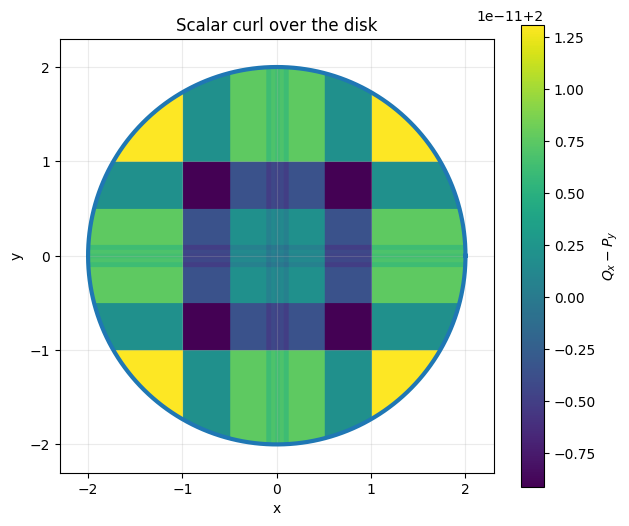

In [11]:
R = 2.0
x, y, X, Y = make_dense_grid(-2.3, 2.3, -2.3, 2.3, n=350)
CURL = numerical_scalar_curl(F_rotational, X, Y)
inside = X**2 + Y**2 <= R**2
CURL_masked = np.where(inside, CURL, np.nan)

plt.figure(figsize=(7, 6))
im = plt.imshow(CURL_masked, extent=[-2.3,2.3,-2.3,2.3], origin="lower", aspect="equal")
theta = np.linspace(0, 2*np.pi, 600)
plt.plot(R*np.cos(theta), R*np.sin(theta), linewidth=3)
plt.colorbar(im, label=r"$Q_x-P_y$")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scalar curl over the disk")
plt.grid(True, alpha=0.25)
plt.show()

## 10. Green's theorem on a rectangle

Let

$$
\mathbf F(x,y)=\langle -y^2,\;x^2\rangle.
$$

Then

$$
Q_x-P_y=2x-(-2y)=2x+2y.
$$

Use the rectangle

$$
D=[0,2]\times[0,1].
$$

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Line integral around rectangle: 6.0
Green theorem grid integral: 6.0
Exact Green integral: 6.0


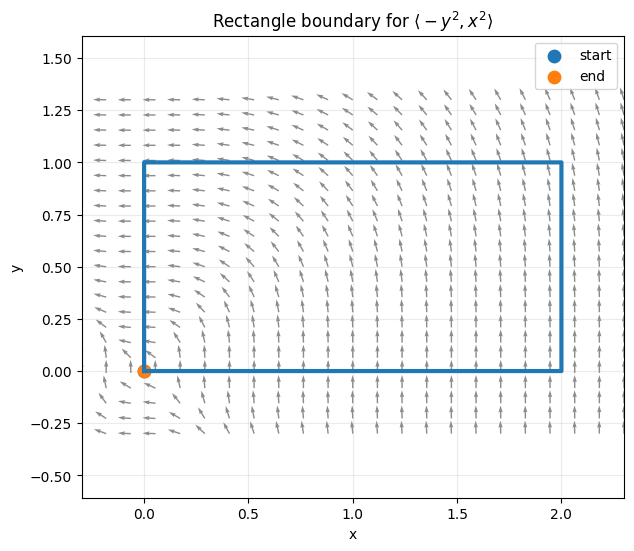

In [12]:
def F_poly(X, Y):
    return -Y**2, X**2

def scalar_curl_poly(X, Y):
    return 2*X + 2*Y

# Positively oriented rectangle boundary.
rect_pts = piecewise_points([[0,0], [2,0], [2,1], [0,1], [0,0]], points_per_segment=500)

line_rect, *_ = sampled_vector_line_integral(F_poly, rect_pts)

# Double integral: ∫_0^2∫_0^1 (2x+2y) dy dx
green_exact = 6.0
green_grid, *_ = midpoint_region_integral(
    scalar_curl_poly,
    0, 2, 0, 1,
    rectangle_mask(0,2,0,1),
    nx=500, ny=300
)

print("Line integral around rectangle:", line_rect)
print("Green theorem grid integral:", green_grid)
print("Exact Green integral:", green_exact)

plot_path_in_field(F_poly, rect_pts, xmin=-0.3, xmax=2.3, ymin=-0.3, ymax=1.3,
                   title=r"Rectangle boundary for $\langle -y^2,x^2\rangle$")

---

# Part V. Orientation

Green's theorem uses **positive orientation**, meaning the curve is traversed counterclockwise so the region stays on the left.

Reversing orientation changes the sign of the line integral:

$$
\oint_{-C} P\,dx+Q\,dy
=
-\oint_C P\,dx+Q\,dy.
$$

## 11. Reverse the rectangle orientation

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Counterclockwise rectangle integral: 6.0
Clockwise rectangle integral: -6.0
Sum: 0.0


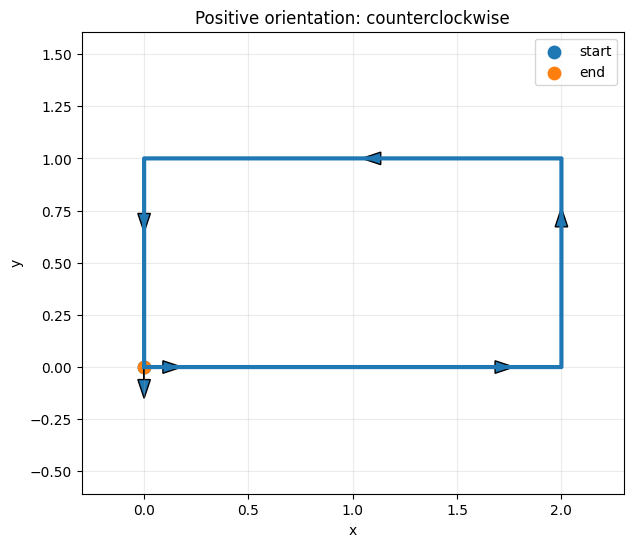

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


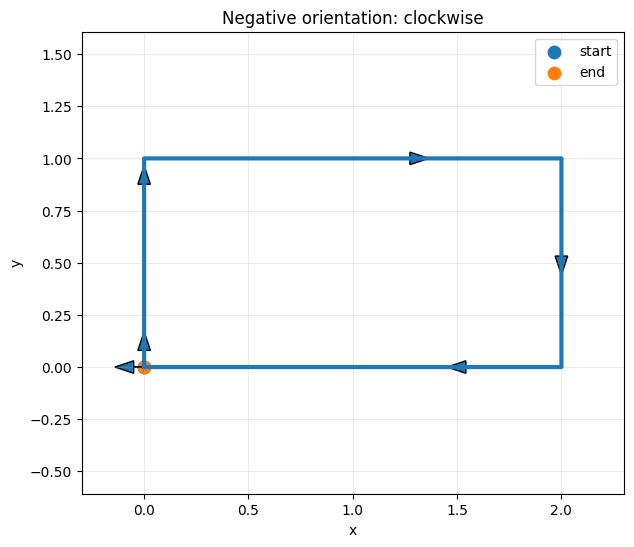

In [13]:
rect_pts_reverse = rect_pts[::-1]

line_rect_reverse, *_ = sampled_vector_line_integral(F_poly, rect_pts_reverse)

print("Counterclockwise rectangle integral:", line_rect)
print("Clockwise rectangle integral:", line_rect_reverse)
print("Sum:", line_rect + line_rect_reverse)

plot_path(rect_pts, xmin=-0.3, xmax=2.3, ymin=-0.3, ymax=1.3,
          title="Positive orientation: counterclockwise")
plot_path(rect_pts_reverse, xmin=-0.3, xmax=2.3, ymin=-0.3, ymax=1.3,
          title="Negative orientation: clockwise")

---

# Part VI. Area from Green's theorem

Choose

$$
P=-\frac{y}{2},\qquad Q=\frac{x}{2}.
$$

Then

$$
Q_x-P_y=\frac12-\left(-\frac12\right)=1.
$$

So Green's theorem gives the area formula

$$
\operatorname{Area}(D)
=
\oint_C -\frac y2\,dx+\frac x2\,dy.
$$

Equivalently,

$$
\operatorname{Area}(D)
=
\frac12\oint_C x\,dy-y\,dx.
$$

## 12. Area of a circle from a line integral

In [14]:
def F_area(X, Y):
    return -0.5*Y, 0.5*X

for R in [0.5, 1.0, 2.5]:
    rR, rpR = make_circle(R)
    area_line, *_ = vector_line_integral(F_area, rR, rpR, 0, 2*np.pi, n=6000)
    print(f"R={R:3.1f}: line-integral area={area_line:12.6f}, exact area={np.pi*R**2:12.6f}")

R=0.5: line-integral area=    0.785398, exact area=    0.785398
R=1.0: line-integral area=    3.141593, exact area=    3.141593
R=2.5: line-integral area=   19.634954, exact area=   19.634954


## 13. Area of an ellipse from a parametrization

For the ellipse

$$
x=a\cos t,\qquad y=b\sin t,
$$

the area should be

$$
\pi ab.
$$

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ellipse area by Green's theorem: 14.137166941154069
Exact area: 14.137166941154069


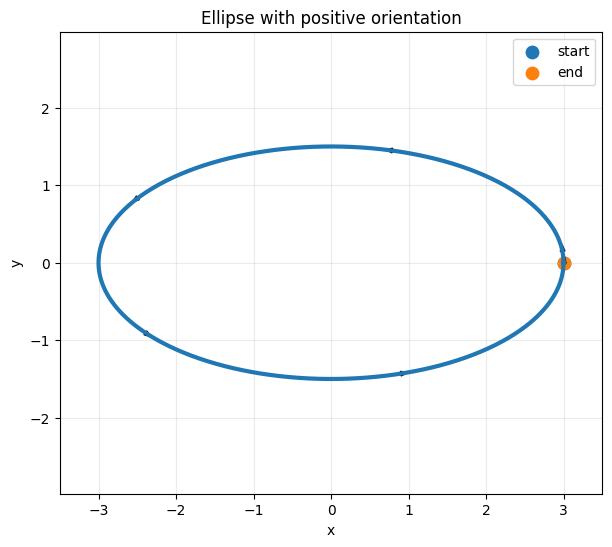

In [15]:
a, b = 3.0, 1.5

def r_ellipse(t):
    return a*np.cos(t), b*np.sin(t)

def rp_ellipse(t):
    return -a*np.sin(t), b*np.cos(t)

ellipse_area_line, *_ = vector_line_integral(F_area, r_ellipse, rp_ellipse, 0, 2*np.pi, n=6000)

print("Ellipse area by Green's theorem:", ellipse_area_line)
print("Exact area:", np.pi*a*b)

path_ellipse = np.column_stack(r_ellipse(np.linspace(0, 2*np.pi, 600)))
plot_path(path_ellipse, xmin=-3.5, xmax=3.5, ymin=-2, ymax=2,
          title="Ellipse with positive orientation")

## 14. Area of a polygon by Green's theorem

The shoelace formula is a discrete version of the same idea.

For a closed polygon,

$$
\operatorname{Area}
=
\frac12\sum_i (x_i y_{i+1}-y_i x_{i+1}).
$$

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Signed polygon area by shoelace: 4.904999999999999
Area line integral: 4.904999999999999


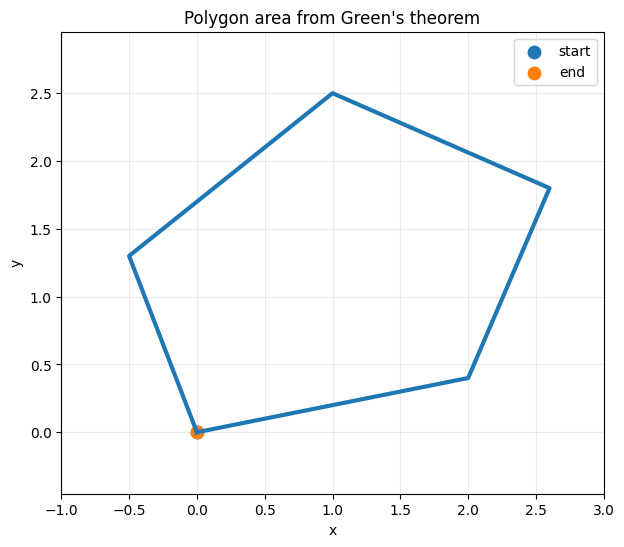

In [16]:
polygon = np.array([
    [0.0, 0.0],
    [2.0, 0.4],
    [2.6, 1.8],
    [1.0, 2.5],
    [-0.5, 1.3],
    [0.0, 0.0]
])

poly_area_signed = sampled_area_signed(polygon)
poly_line_area, *_ = sampled_vector_line_integral(F_area, polygon)

print("Signed polygon area by shoelace:", poly_area_signed)
print("Area line integral:", poly_line_area)

plot_path(polygon, xmin=-1, xmax=3, ymin=-0.5, ymax=3,
          title="Polygon area from Green's theorem")

---

# Part VII. General-region numerical Green checks

For more complicated regions, we can compare:

1. a sampled boundary line integral;
2. a grid approximation of the double integral over the enclosed region.

This is not a symbolic proof, but it is a powerful computational check.

## 15. A smooth wavy closed curve

Define a positively oriented curve in polar-like form:

$$
r(t)=1.5+0.35\cos(3t)+0.15\sin(5t),
$$

$$
x(t)=r(t)\cos t,\qquad y(t)=r(t)\sin t.
$$

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


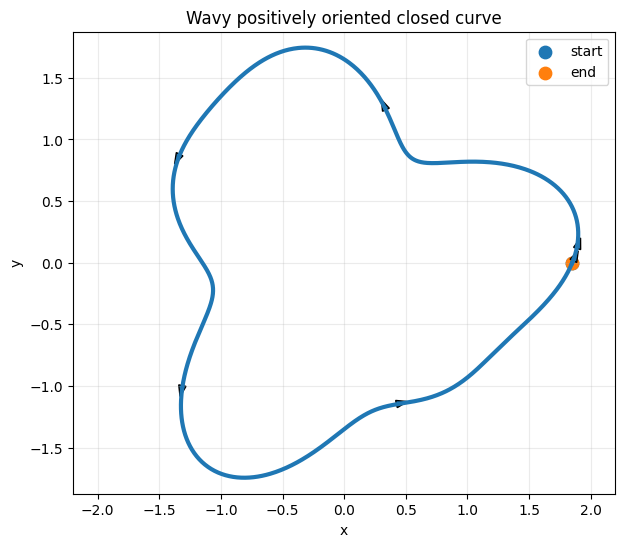

Signed area by boundary formula: 7.296279633963234


In [17]:
def radius_wavy(t):
    return 1.5 + 0.35*np.cos(3*t) + 0.15*np.sin(5*t)

def radius_wavy_prime(t):
    return -1.05*np.sin(3*t) + 0.75*np.cos(5*t)

def r_wavy(t):
    R = radius_wavy(t)
    return R*np.cos(t), R*np.sin(t)

def rp_wavy(t):
    R = radius_wavy(t)
    Rp = radius_wavy_prime(t)
    return Rp*np.cos(t) - R*np.sin(t), Rp*np.sin(t) + R*np.cos(t)

tw = np.linspace(0, 2*np.pi, 1200)
wavy_pts = np.column_stack(r_wavy(tw))

plot_path(wavy_pts, xmin=-2.2, xmax=2.2, ymin=-2.2, ymax=2.2,
          title="Wavy positively oriented closed curve")
print("Signed area by boundary formula:", sampled_area_signed(wavy_pts))

## 16. Green's theorem for the wavy curve

Use

$$
\mathbf F(x,y)=\langle -y^2,\;x^2\rangle,
$$

so the scalar curl is

$$
2x+2y.
$$

The boundary line integral should equal the double integral of $2x+2y$ over the wavy region.

Boundary line integral: -0.028863382504857427
Region double integral: -0.030490128000001192
Difference: 0.0016267454951437652


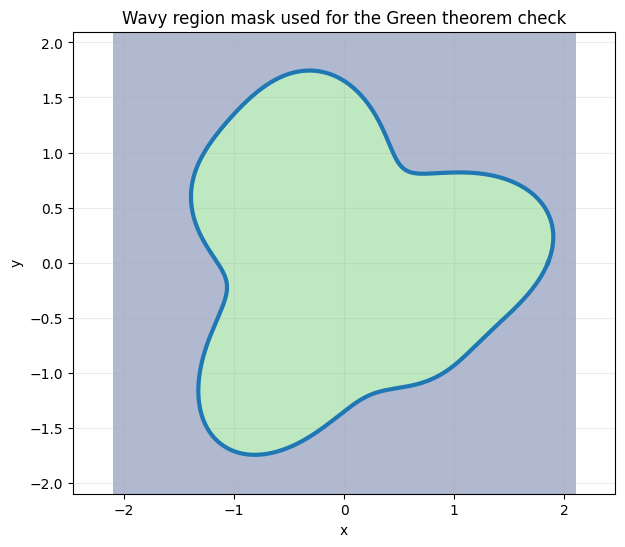

In [18]:
line_wavy, *_ = vector_line_integral(F_poly, r_wavy, rp_wavy, 0, 2*np.pi, n=8000)

# Mask for the wavy polar region: inside if rho <= radius_wavy(theta)
def wavy_mask(X, Y):
    theta = np.mod(np.arctan2(Y, X), 2*np.pi)
    rho = np.sqrt(X**2 + Y**2)
    return rho <= radius_wavy(theta)

green_wavy, X, Y, Zcurl, inside = midpoint_region_integral(
    scalar_curl_poly,
    -2.1, 2.1,
    -2.1, 2.1,
    wavy_mask,
    nx=700,
    ny=700
)

print("Boundary line integral:", line_wavy)
print("Region double integral:", green_wavy)
print("Difference:", line_wavy - green_wavy)

plt.figure(figsize=(7, 6))
plt.contourf(X, Y, inside.astype(float), levels=[-0.5,0.5,1.5], alpha=0.4)
plt.plot(wavy_pts[:,0], wavy_pts[:,1], linewidth=3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Wavy region mask used for the Green theorem check")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part VIII. Flux form of Green's theorem

For a vector field

$$
\mathbf F=\langle P,Q\rangle,
$$

the outward flux across a positively oriented closed curve can be written as

$$
\oint_C \mathbf F\cdot \mathbf n\,ds
=
\oint_C P\,dy-Q\,dx.
$$

Green's theorem gives

$$
\oint_C P\,dy-Q\,dx
=
\iint_D (P_x+Q_y)\,dA
=
\iint_D \nabla\cdot \mathbf F\,dA.
$$

## 17. Flux through a circle for a radial field

Let

$$
\mathbf F(x,y)=\langle x,y\rangle.
$$

The divergence is

$$
P_x+Q_y=2.
$$

For a circle of radius $R$,

$$
\oint_C \mathbf F\cdot\mathbf n\,ds
=
\iint_D2\,dA
=
2\pi R^2.
$$

In [19]:
def F_radial(X, Y):
    return X, Y

for R in [0.5, 1.0, 2.0, 3.0]:
    rR, rpR = make_circle(R)
    flux_val, *_ = flux_line_integral(F_radial, rR, rpR, 0, 2*np.pi, n=6000)
    print(f"R={R:3.1f}: flux integral={flux_val:12.6f}, exact={2*np.pi*R**2:12.6f}")

R=0.5: flux integral=    1.570796, exact=    1.570796
R=1.0: flux integral=    6.283185, exact=    6.283185
R=2.0: flux integral=   25.132741, exact=   25.132741
R=3.0: flux integral=   56.548668, exact=   56.548668


## 18. Flux form on a rectangle

Let

$$
\mathbf F=\langle x^2,y^2\rangle.
$$

Then

$$
\nabla\cdot\mathbf F=2x+2y.
$$

Use the same rectangle $[0,2]\times[0,1]$.

In [20]:
def F_flux_poly(X, Y):
    return X**2, Y**2

def div_flux_poly(X, Y):
    return 2*X + 2*Y

flux_rect, *_ = sampled_flux_line_integral(F_flux_poly, rect_pts)

div_rect, *_ = midpoint_region_integral(
    div_flux_poly,
    0, 2, 0, 1,
    rectangle_mask(0,2,0,1),
    nx=500,
    ny=300
)

print("Boundary flux integral:", flux_rect)
print("Double integral of divergence:", div_rect)
print("Exact value:", 6.0)

Boundary flux integral: 6.0
Double integral of divergence: 6.0
Exact value: 6.0


## 19. Divergence and flux interpretation

Positive divergence means local sources or expansion.  
Negative divergence means local sinks or compression.  
Zero divergence means locally area-preserving flow, though the field may still rotate.

In [21]:
fields = [
    ("radial source <x,y>", F_radial),
    ("rotational <-y,x>", F_rotational),
    ("flux polynomial <x^2,y^2>", F_flux_poly),
]

for name, F in fields:
    print(name)
    for p in [(0,0), (1,0.5), (-1,2)]:
        div = numerical_divergence(F, p[0], p[1])
        curl = numerical_scalar_curl(F, p[0], p[1])
        print(f"  point {p}: divergence={div: .6f}, scalar curl={curl: .6f}")
    print()

radial source <x,y>
  point (0, 0): divergence= 2.000000, scalar curl= 0.000000
  point (1, 0.5): divergence= 2.000000, scalar curl= 0.000000
  point (-1, 2): divergence= 2.000000, scalar curl= 0.000000

rotational <-y,x>
  point (0, 0): divergence= 0.000000, scalar curl= 2.000000
  point (1, 0.5): divergence= 0.000000, scalar curl= 2.000000
  point (-1, 2): divergence= 0.000000, scalar curl= 2.000000

flux polynomial <x^2,y^2>
  point (0, 0): divergence= 0.000000, scalar curl= 0.000000
  point (1, 0.5): divergence= 3.000000, scalar curl= 0.000000
  point (-1, 2): divergence= 2.000000, scalar curl= 0.000000



---

# Part IX. Green's theorem as a computational tool

Green's theorem allows us to replace a boundary integral with an area integral, or vice versa.

This is useful when:

- the boundary is easier than the region;
- the region is easier than the boundary;
- the integrand simplifies after taking scalar curl or divergence;
- the curve is given by sampled data.

## 20. Compute area from sampled boundary data

We generate a noisy sampled closed curve and estimate the enclosed area using the boundary formula

$$
A=\frac12\oint_C x\,dy-y\,dx.
$$

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Signed area by shoelace: 8.151734620249625
Area from F_area line integral: 8.151734620249627


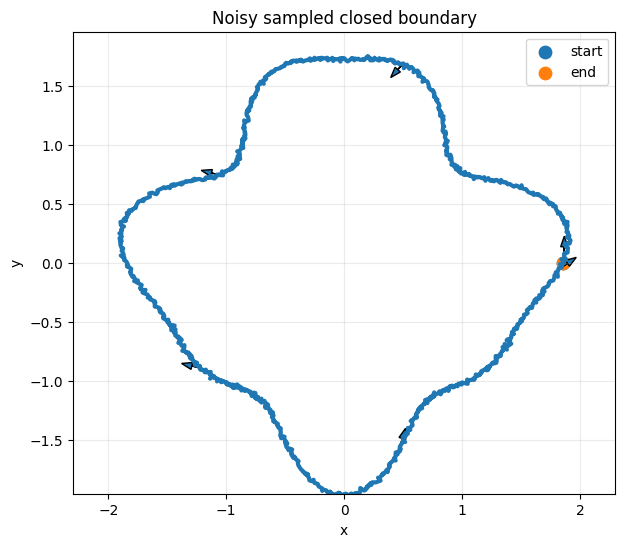

In [22]:
rng = np.random.default_rng(21)

t = np.linspace(0, 2*np.pi, 1000, endpoint=True)
R_clean = 1.6 + 0.25*np.cos(4*t) + 0.12*np.sin(7*t)
x_clean = R_clean*np.cos(t)
y_clean = R_clean*np.sin(t)

noise = 0.01
x_noisy = x_clean + rng.normal(scale=noise, size=t.shape)
y_noisy = y_clean + rng.normal(scale=noise, size=t.shape)
sampled_loop = close_polyline(np.column_stack([x_noisy, y_noisy]))

area_sampled = sampled_area_signed(sampled_loop)
area_from_F_area, *_ = sampled_vector_line_integral(F_area, sampled_loop)

print("Signed area by shoelace:", area_sampled)
print("Area from F_area line integral:", area_from_F_area)

plot_path(sampled_loop, xmin=-2.3, xmax=2.3, ymin=-2.3, ymax=2.3,
          title="Noisy sampled closed boundary")

## 21. Orientation detection

The sign of the area tells us orientation.

- Positive signed area: counterclockwise;
- Negative signed area: clockwise.

In [23]:
sampled_loop_reverse = sampled_loop[::-1]
area_reverse = sampled_area_signed(sampled_loop_reverse)

print("Original signed area:", area_sampled)
print("Reversed signed area:", area_reverse)
print("Sum:", area_sampled + area_reverse)

Original signed area: 8.151734620249625
Reversed signed area: -8.151734620249627
Sum: -1.7763568394002505e-15


---

# Part X. Multiply connected regions

Green's theorem extends to regions with holes.  
The outer boundary is positively oriented counterclockwise, while inner hole boundaries are oriented clockwise.

For an annulus

$$
a\leq r\leq b,
$$

the positive boundary consists of:

- outer circle counterclockwise;
- inner circle clockwise.

## 22. Annulus circulation for the rotational field

For

$$
\mathbf F=\langle -y,x\rangle,
$$

scalar curl is $2$.

For annulus $a\leq r\leq b$,

$$
\oint_{\partial D}\mathbf F\cdot d\mathbf r
=
\iint_D2\,dA
=
2\pi(b^2-a^2).
$$

Outer boundary contribution: 39.269908169872416
Inner clockwise contribution: -6.283185307179586
Total annulus boundary integral: 32.98672286269283
Green theorem prediction: 32.98672286269283


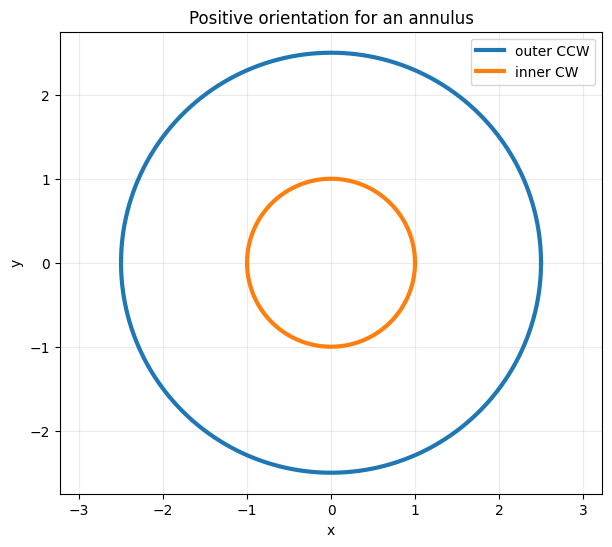

In [24]:
a_inner = 1.0
b_outer = 2.5

r_outer, rp_outer = make_circle(b_outer)
r_inner_ccw, rp_inner_ccw = make_circle(a_inner)

# Inner boundary must be clockwise for positive orientation of annulus.
def r_inner_clockwise(t):
    return a_inner*np.cos(-t), a_inner*np.sin(-t)

def rp_inner_clockwise(t):
    return a_inner*np.sin(-t), -a_inner*np.cos(-t)

outer_val, *_ = vector_line_integral(F_rotational, r_outer, rp_outer, 0, 2*np.pi, n=6000)
inner_clockwise_val, *_ = vector_line_integral(F_rotational, r_inner_clockwise, rp_inner_clockwise, 0, 2*np.pi, n=6000)
annulus_boundary_val = outer_val + inner_clockwise_val
green_annulus = 2*np.pi*(b_outer**2 - a_inner**2)

print("Outer boundary contribution:", outer_val)
print("Inner clockwise contribution:", inner_clockwise_val)
print("Total annulus boundary integral:", annulus_boundary_val)
print("Green theorem prediction:", green_annulus)

theta = np.linspace(0, 2*np.pi, 600)
plt.figure(figsize=(7, 6))
plt.plot(b_outer*np.cos(theta), b_outer*np.sin(theta), linewidth=3, label="outer CCW")
plt.plot(a_inner*np.cos(-theta), a_inner*np.sin(-theta), linewidth=3, label="inner CW")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Positive orientation for an annulus")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Part XI. Chapter mini-project: circulation, area, and Green's theorem

In this mini-project, you will compare three quantities for a family of closed curves:

1. the signed area from Green's theorem;
2. circulation in the rotational field $\langle -y,x\rangle$;
3. the double integral of scalar curl.

For a positively oriented curve $C$ enclosing $D$,

$$
\oint_C \langle -y,x\rangle\cdot d\mathbf r
=
\iint_D2\,dA
=
2\,\operatorname{Area}(D).
$$

So the circulation in this field should be twice the enclosed signed area.

## 23. Generate a family of star-shaped curves

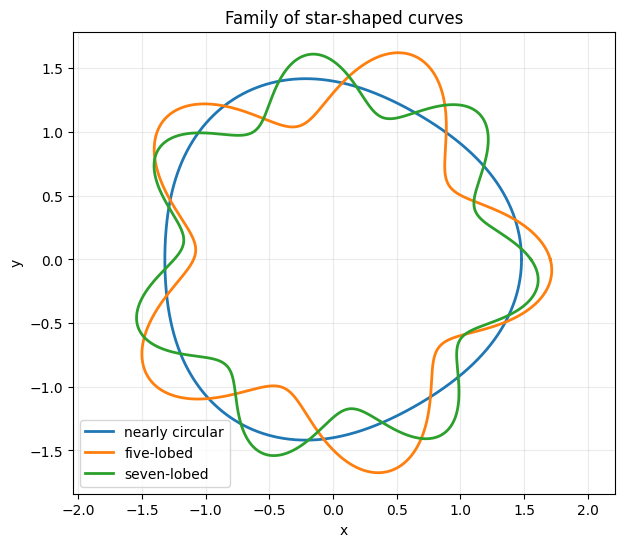

In [25]:
def star_curve_points(a=1.4, eps=0.25, k=5, phase=0.0, n=1600):
    t = np.linspace(0, 2*np.pi, n, endpoint=True)
    R = a + eps*np.cos(k*t + phase)
    X = R*np.cos(t)
    Y = R*np.sin(t)
    return close_polyline(np.column_stack([X, Y]))

curves = [
    ("nearly circular", star_curve_points(a=1.4, eps=0.08, k=3, phase=0.0)),
    ("five-lobed", star_curve_points(a=1.4, eps=0.32, k=5, phase=0.3)),
    ("seven-lobed", star_curve_points(a=1.4, eps=0.22, k=7, phase=0.8)),
]

plt.figure(figsize=(7, 6))
for name, pts in curves:
    plt.plot(pts[:,0], pts[:,1], linewidth=2, label=name)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Family of star-shaped curves")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 24. Compare area and circulation

In [26]:
print(f"{'curve':>18s} {'area':>14s} {'circulation':>16s} {'2 area':>14s} {'difference':>14s}")
for name, pts in curves:
    area = sampled_area_signed(pts)
    circulation, *_ = sampled_vector_line_integral(F_rotational, pts)
    print(f"{name:>18s} {area:14.8f} {circulation:16.8f} {2*area:14.8f} {circulation-2*area:14.2e}")

             curve           area      circulation         2 area     difference
   nearly circular     6.16755813      12.33511625    12.33511625      -3.55e-15
        five-lobed     6.31832384      12.63664768    12.63664768       3.55e-15
       seven-lobed     6.23350334      12.46700669    12.46700669       3.55e-15


## 25. Mini-project questions

Answer the following in a markdown cell:

1. Why is the circulation of $\langle -y,x\rangle$ equal to twice the area?
2. How does reversing orientation affect signed area and circulation?
3. Which curve has the largest area? Does it also have the largest circulation?
4. Why is Green's theorem useful when the curve is complicated?
5. How would the calculation change for a field whose scalar curl is not constant?

In [27]:
# Reverse one curve to test orientation.
name, pts = curves[1]
pts_rev = pts[::-1]
area_rev = sampled_area_signed(pts_rev)
circ_rev, *_ = sampled_vector_line_integral(F_rotational, pts_rev)

print("Original curve:", name)
print("Original area:", sampled_area_signed(pts))
print("Original circulation:", sampled_vector_line_integral(F_rotational, pts)[0])
print("Reversed area:", area_rev)
print("Reversed circulation:", circ_rev)

Original curve: five-lobed
Original area: 6.3183238410641
Original circulation: 12.636647682128203
Reversed area: -6.3183238410641
Reversed circulation: -12.636647682128203


---

# Part XII. Additional exercises with reference solutions

Try each exercise before running the reference solution.

## Exercise A. Conservative test

Determine whether

$$
\mathbf F(x,y)=\langle 3x^2y+2y,\;x^3+2x+4y\rangle
$$

is conservative. If so, find a potential.

In [28]:
# Exercise A workspace

# Your code here

### Reference solution for Exercise A

In [29]:
def F_A(X, Y):
    return 3*X**2*Y + 2*Y, X**3 + 2*X + 4*Y

def potential_A(X, Y):
    return X**3*Y + 2*X*Y + 2*Y**2

for p in [(0,0), (1,2), (-1,0.5)]:
    curl = numerical_scalar_curl(F_A, p[0], p[1])
    print("point:", p, "scalar curl:", curl)

print("Potential: f(x,y)=x^3 y + 2xy + 2y^2")

point: (0, 0) scalar curl: 1.000000082740371e-10
point: (1, 2) scalar curl: -8.881784197001252e-11
point: (-1, 0.5) scalar curl: 1.1102230246251565e-10
Potential: f(x,y)=x^3 y + 2xy + 2y^2


## Exercise B. Line integral using a potential

For the field in Exercise A, compute the line integral from $(0,0)$ to $(1,2)$.

In [30]:
# Exercise B workspace

# Your code here

### Reference solution for Exercise B

In [31]:
A_B = np.array([0.0, 0.0])
B_B = np.array([1.0, 2.0])

def r_B(t):
    return A_B[0] + t*(B_B[0]-A_B[0]), A_B[1] + t*(B_B[1]-A_B[1])

def rp_B(t):
    return (B_B[0]-A_B[0])*np.ones_like(t), (B_B[1]-A_B[1])*np.ones_like(t)

I_B, *_ = vector_line_integral(F_A, r_B, rp_B, 0, 1)
delta_B = potential_A(B_B[0], B_B[1]) - potential_A(A_B[0], A_B[1])

print("Line integral:", I_B)
print("Potential difference:", delta_B)

Line integral: 14.000000222370444
Potential difference: 14.0


## Exercise C. Green's theorem on a disk

Use Green's theorem to compute

$$
\oint_C -3y\,dx+3x\,dy
$$

where $C$ is the circle of radius $2$ oriented counterclockwise.

In [32]:
# Exercise C workspace

# Your code here

### Reference solution for Exercise C

In [33]:
def F_C(X, Y):
    return -3*Y, 3*X

r2, rp2 = make_circle(2.0)
I_C, *_ = vector_line_integral(F_C, r2, rp2, 0, 2*np.pi, n=6000)

# Scalar curl = Q_x - P_y = 3 - (-3) = 6.
# Area = 4π. Integral = 24π.
print("Line integral:", I_C)
print("Green theorem value:", 24*np.pi)

Line integral: 75.39822368615503
Green theorem value: 75.39822368615503


## Exercise D. Area from boundary

Compute the area enclosed by

$$
x=2\cos t,\qquad y=3\sin t,\qquad 0\leq t\leq2\pi
$$

using

$$
A=\frac12\oint_C x\,dy-y\,dx.
$$

In [34]:
# Exercise D workspace

# Your code here

### Reference solution for Exercise D

In [35]:
def r_D(t):
    return 2*np.cos(t), 3*np.sin(t)

def rp_D(t):
    return -2*np.sin(t), 3*np.cos(t)

A_D, *_ = vector_line_integral(F_area, r_D, rp_D, 0, 2*np.pi, n=6000)

print("Area from boundary integral:", A_D)
print("Exact ellipse area:", 6*np.pi)

Area from boundary integral: 18.84955592153876
Exact ellipse area: 18.84955592153876


## Exercise E. Flux form

Use the flux form of Green's theorem to compute the outward flux of

$$
\mathbf F(x,y)=\langle x,y\rangle
$$

across the boundary of the rectangle $[0,3]\times[0,2]$.

In [36]:
# Exercise E workspace

# Your code here

### Reference solution for Exercise E

In [37]:
rect_E = piecewise_points([[0,0], [3,0], [3,2], [0,2], [0,0]], points_per_segment=500)
flux_E, *_ = sampled_flux_line_integral(F_radial, rect_E)

# divergence = 2, area = 6, flux = 12.
print("Boundary flux integral:", flux_E)
print("Green theorem value:", 12.0)

Boundary flux integral: 12.0
Green theorem value: 12.0


---

# Formula summary

## Conservative field

$$
\mathbf F=\nabla f.
$$

## Fundamental theorem for line integrals

If $\mathbf F=\nabla f$ and $C$ goes from $A$ to $B$, then

$$
\int_C\mathbf F\cdot d\mathbf r=f(B)-f(A).
$$

## Conservative test in the plane

For

$$
\mathbf F=\langle P,Q\rangle,
$$

a necessary condition is

$$
P_y=Q_x.
$$

On a simply connected region, this condition is also sufficient for smooth fields.

## Scalar curl in the plane

$$
\operatorname{curl}\mathbf F=Q_x-P_y.
$$

## Green's theorem: circulation form

For positively oriented $C=\partial D$,

$$
\oint_C P\,dx+Q\,dy
=
\iint_D(Q_x-P_y)\,dA.
$$

## Area formula

$$
\operatorname{Area}(D)
=
\frac12\oint_C x\,dy-y\,dx.
$$

## Green's theorem: flux form

$$
\oint_C P\,dy-Q\,dx
=
\iint_D(P_x+Q_y)\,dA.
$$

## Divergence in the plane

$$
\nabla\cdot\mathbf F=P_x+Q_y.
$$

## Orientation

Counterclockwise orientation is positive for an outer boundary.  
For holes, positive orientation means clockwise around the inner boundary.

# End of Chapter 21 Lab

You have used Python to explore:

- conservative vector fields,
- potentials and path independence,
- scalar curl tests,
- potential reconstruction,
- Green's theorem in circulation form,
- orientation and sign,
- area from boundary integrals,
- polygon area and sampled curve area,
- numerical Green theorem checks over general regions,
- flux form of Green's theorem,
- annular regions with holes,
- and a mini-project connecting circulation and area.

These ideas prepare for surface integrals, curl and divergence in three dimensions, Stokes' theorem, the divergence theorem, and the global structure of vector calculus.